In [1]:
# Author: Arthur Prigent
# Email: arthur.prigent@univ-brest.fr

In [2]:
# import library
import numpy as np
import matplotlib.pyplot as plt
import netCDF4
import xarray as xr
import gsw
from mpl_toolkits.basemap import Basemap
import datetime as dt
from scipy.interpolate import Akima1DInterpolator
import glob

import matplotlib.path as mpath
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

import ArcTools as Atools

In [3]:

dir_clim = '/data0/user/aprigent/ISAS/ISAS17_Mask.nc'
mask = xr.open_dataset(dir_clim)
zi = mask.depthCFD.data

In [4]:
def split_ragged(flat_array, row_sizes):
    """
    Split a 1-D flat array into a list of per-cast arrays using row_sizes.
    Returns one array per cast, including empty arrays (length 0).
    """
    starts = np.concatenate([[0], np.cumsum(row_sizes)[:-1]])
    return [flat_array[s : s + n] for s, n in zip(starts, row_sizes)]


def interp_prof(z_obs, y_obs, z_new):
    """
    Interpolate a single profile (z_obs, y_obs) onto z_new using
    Akima1DInterpolator. Returns NaN where interpolation is not possible.

    Parameters
    ----------
    z_obs : array-like  Observed depths (may contain duplicates / NaNs)
    y_obs : array-like  Observed values  (may contain NaNs)
    z_new : array-like  Target depth grid
    """
    z_new = np.asarray(z_new, dtype=float)

    # Deduplicate depths (keep first occurrence)
    z_u, i_uniq = np.unique(z_obs, return_index=True)
    y_u = np.asarray(y_obs, dtype=float)[i_uniq]

    # Mask invalid pairs
    valid = np.isfinite(z_u) & np.isfinite(y_u)

    if valid.sum() > 1:
        spl = Akima1DInterpolator(z_u[valid], y_u[valid])
        return spl(z_new)
    else:
        return np.full_like(z_new, np.nan)

In [5]:
ds = xr.open_dataset('/data0/user/aprigent/WOD/ocldb1773244274.1070292_CTD.nc',decode_times=False)
n_casts = ds.dims["casts"]   # number of casts in the file

# ─────────────────────────────────────────────────────────────
# Metadata
# ─────────────────────────────────────────────────────────────

# WOD time origin: 1770-01-01
# time_origin = dt.datetime(1770, 1, 1).toordinal()
# time = np.array([dt.datetime.fromordinal(time_origin + int(t))
#                  for t in ds["time"].values])
# WOD time origin: 1770-01-01
time_origin = dt.datetime(1770, 1, 1).toordinal()

# Keep time as ordinal relative to origin
time = np.array([time_origin + int(t) for t in ds["time"].values])

lat = ds["lat"].values          # (n_casts,)
lon = ds["lon"].values          # (n_casts,)

In [7]:
"""
WOD23 profile processing script
--------------------------------
Reads a WOD23 netCDF file, interpolates Temperature and Salinity
profiles onto the ISAS vertical grid, and saves the output.

"""

# ─────────────────────────────────────────────────────────────
# Configuration
# ─────────────────────────────────────────────────────────────

list_CTD = glob.glob('/data0/user/aprigent/WOD/*_CTD*.nc')
data_out = '/data0/user/aprigent/WOD/processed/'

# ─────────────────────────────────────────────────────────────
# Load dataset
# ─────────────────────────────────────────────────────────────
for k in range(len(list_CTD)):
    print("Loading dataset …",list_CTD[k])
    ds = xr.open_dataset(list_CTD[k], decode_times=False)
    
    n_casts = ds.dims["casts"]   # number of casts in the file
    
    # ─────────────────────────────────────────────────────────────
    # Metadata
    # ─────────────────────────────────────────────────────────────
    
    # WOD time origin: 1770-01-01
    time_origin = dt.datetime(1770, 1, 1).toordinal()

    # Keep time as ordinal relative to origin
    time = np.array([time_origin + int(t) for t in ds["time"].values])
    
    lat = ds["lat"].values          # (n_casts,)
    lon = ds["lon"].values          # (n_casts,)
    

    # Row sizes  — each variable has its own ragged structure

    
    z_row    = ds["z_row_size"].values.astype(int)
    z_row[z_row < 0]    = 0
    temp_row = ds["Temperature_row_size"].values.astype(int)
    temp_row[temp_row < 0] = 0
    salt_row = ds["Salinity_row_size"].values.astype(int)
    salt_row[salt_row < 0] = 0
    
    print(f"  Casts : {n_casts}")
    print(f"  z obs : {z_row.sum()}")
    print(f"  T obs : {temp_row.sum()}")
    print(f"  S obs : {salt_row.sum()}")
    

    # Flat arrays

    z_flat     = ds["z"].values
    temp_flat  = ds["Temperature"].values
    salt_flat  = ds["Salinity"].values
    T_flag_flat = ds["Temperature_WODflag"].values
    S_flag_flat = ds["Salinity_WODflag"].values
    

    # Split into per-cast lists  (length = n_casts each)
 
    
    print("Splitting ragged arrays …")
    z_prof      = split_ragged(z_flat,      z_row)
    temp_prof   = split_ragged(temp_flat,   temp_row)
    salt_prof   = split_ragged(salt_flat,   salt_row)
    Tflag_prof  = split_ragged(T_flag_flat, temp_row)
    Sflag_prof  = split_ragged(S_flag_flat, salt_row)
    

    # Sanity checks  (run on all casts)

    print("Running sanity checks …")
    for i in range(n_casts):
        assert len(z_prof[i])     == z_row[i],    f"Cast {i}: z mismatch"
        assert len(temp_prof[i])  == temp_row[i], f"Cast {i}: T mismatch"
        assert len(salt_prof[i])  == salt_row[i], f"Cast {i}: S mismatch"
        assert len(Tflag_prof[i]) == temp_row[i], f"Cast {i}: Tflag mismatch"
        assert len(Sflag_prof[i]) == salt_row[i], f"Cast {i}: Sflag mismatch"
    
        # z must cover at least as many levels as T and S
        if temp_row[i] > 0:
            assert z_row[i] >= temp_row[i], \
                f"Cast {i}: z ({z_row[i]}) < T ({temp_row[i]})"
        if salt_row[i] > 0:
            assert z_row[i] >= salt_row[i], \
                f"Cast {i}: z ({z_row[i]}) < S ({salt_row[i]})"
    
    print("  All checks passed.")
    # ─────────────────────────────────────────────────────────────
    # Compute profile summaries (for later duplicate detection)
    # ─────────────────────────────────────────────────────────────

    print("Computing profile summaries …")

    n_levels_temp = temp_row.copy()
    n_levels_salt  = salt_row.copy()

    sum_depth_temp = np.full(n_casts, np.nan)
    sum_depth_salt  = np.full(n_casts, np.nan)

    sum_temp = np.full(n_casts, np.nan)
    sum_salt  = np.full(n_casts, np.nan)

    for i in range(n_casts):

        if temp_row[i] > 0:
            sum_depth_temp[i] = np.sum(z_prof[i][:temp_row[i]])
            sum_temp[i]       = np.sum(temp_prof[i][:temp_row[i]])

        if salt_row[i] > 0:
            sum_depth_salt[i] = np.sum(z_prof[i][:salt_row[i]])
            sum_salt[i]       = np.sum(salt_prof[i][:salt_row[i]])




    



    T_profile_flag = ds["Temperature_WODprofileflag"].values
    S_profile_flag = ds["Salinity_WODprofileflag"].values

    n_casts_ = len(lat)
 

    print(f"  {n_casts} casts remaining.")

    
    
    

#         # Profile-level QC flags

#     T_profile_flag = ds["Temperature_WODprofileflag"].values   # (n_casts,)
#     S_profile_flag = ds["Salinity_WODprofileflag"].values      # (n_casts,)
    
    # ─────────────────────────────────────────────────────────────
    # Interpolation
    # ─────────────────────────────────────────────────────────────
    
    nz = len(zi)
    
    # Output arrays: NaN-filled, indexed by cast
    TEMP = np.full((n_casts, nz), np.nan)
    PSAL = np.full((n_casts, nz), np.nan)
    
    has_T = np.zeros(n_casts, dtype=bool)
    has_S = np.zeros(n_casts, dtype=bool)
    
    print("Interpolating Temperature …")
    for i in range(n_casts):
        if temp_row[i] == 0:
            continue
        if T_profile_flag[i] != 0:          # reject bad profiles
            continue
    
        # Point-level QC: WOD flag 0 = accepted
        good = Tflag_prof[i] == 0
        z_T  = z_prof[i][:temp_row[i]][good]   # z trimmed to T levels, then QC'd
        t_T  = temp_prof[i][good]
    
        if len(z_T) < 2: # remove short profiles
            continue
    
        TEMP[i] = interp_prof(z_T, t_T, zi)
        has_T[i] = True
    
    print(f"  {has_T.sum()} Temperature profiles interpolated.")
    
    print("Interpolating Salinity …")
    for i in range(n_casts):
        if salt_row[i] == 0:
            continue
        if S_profile_flag[i] != 0:
            continue
    
        good = Sflag_prof[i] == 0
        z_S  = z_prof[i][:salt_row[i]][good]   # z trimmed to S levels, then QC'd
        s_S  = salt_prof[i][good]
    
        if len(z_S) < 2: # remove short profiles
            continue
    
        PSAL[i] = interp_prof(z_S, s_S, zi)
        has_S[i] = True
    
    print(f"  {has_S.sum()} Salinity profiles interpolated.")

    
    TEMP[TEMP<-2] = np.nan
    TEMP[TEMP>30] = np.nan
    PSAL[PSAL<0] = np.nan
    PSAL[PSAL>40] = np.nan
    # ─────────────────────────────────────────────────────────────
    # Build output dataset
    # ─────────────────────────────────────────────────────────────
    
    print("Building output dataset …")
    

    
    ds_temp = xr.Dataset(
        {
            "temperature": (["prof", "levels"], TEMP[has_T]),
            "latitude":   (["prof"], lat[has_T]),
            "longitude":   (["prof"], lon[has_T]),
            "time":   (["prof"], time[has_T]),
            "nb_levels": (["prof"], n_levels_temp[has_T]),
            "sum_levels": (["prof"], sum_depth_temp[has_T]),
            "sum_temperature": (["prof"], sum_temp[has_T]),
            "depth": (['levels'], zi),
        },
        coords={'prof': (['prof'], np.arange(0,len(TEMP[has_T]))), 
                'levels':(['levels'], zi)
        },
        attrs={
            "description": "WOD23 T profiles interpolated onto ISAS  vertical grid",
            "depth_grid":  "ISAS vertical grid",
            "QC":          "WOD point flag == 0 and profile flag == 0",
            "created":     str(dt.datetime.utcnow()),
        },
    )
    
    ds_temp["temperature"].attrs.update({"long_name": "Sea Water Temperature T90", "units": "degree_C"})
    ds_temp["time"].attrs.update({"long_name": "Time", "units": "days since 0001-01-01 (Python datetime system)"})
    ds_temp["depth"].attrs.update({"long_name": "Depth", "units": "m", "positive": "down"})

    ds_psal = xr.Dataset(
        {
            "salinity": (["prof", "levels"], PSAL[has_S]),
            "latitude":   (["prof"], lat[has_S]),
            "longitude":   (["prof"], lon[has_S]),
            "time":   (["prof"], time[has_S]),
            "nb_levels": (["prof"], n_levels_salt[has_S]),
            "sum_levels": (["prof"], sum_depth_salt[has_S]),
            "sum_salinity": (["prof"], sum_salt[has_S]),
            "depth": (['levels'], zi)
        },
        coords={'prof': (['prof'], np.arange(0,len(PSAL[has_S]))), 
                'levels':(['levels'], zi)
        },
        attrs={
            "description": "WOD23 S profiles interpolated onto ISAS  vertical grid",
            "depth_grid":  "ISAS vertical grid",
            "QC":          "WOD point flag == 0 and profile flag == 0",
            "created":     str(dt.datetime.utcnow()),
        },
    )

    ds_psal["salinity"].attrs.update({"long_name": "Practical Salinity (PSS78)",    "units": "PSU"})
    ds_psal["depth"].attrs.update({"long_name": "Depth", "units": "m", "positive": "down"})
    ds_psal["time"].attrs.update({"long_name": "Time", "units": "days since 0001-01-01 (Python datetime system)"})
    # ─────────────────────────────────────────────────────────────
    # Save
    # ─────────────────────────────────────────────────────────────
    base_name = os.path.basename(list_CTD[k])
    
    outfile_temp = data_out + base_name[:-3]+'_ISAS_TEMP.nc'
    ds_temp.to_netcdf(outfile_temp)
    print(f"Saved → {outfile_temp}")

    outfile_psal = data_out + base_name[:-3]+'_ISAS_PSAL.nc'
    ds_psal.to_netcdf(outfile_psal)
    print(f"Saved → {outfile_psal}")
    print(f"  {has_T.sum()}  T casts  |  {nz} depth levels")
    print(f"  {has_S.sum()} S casts  |  {nz} depth levels")

Loading dataset … /data0/user/aprigent/WOD/ocldb1773244274.1070292_CTD3.nc
  Casts : 28035
  z obs : 13571897
  T obs : 13571886
  S obs : 13542638
Splitting ragged arrays …
Running sanity checks …
  All checks passed.
Computing profile summaries …
  28035 casts remaining.
Interpolating Temperature …
  26978 Temperature profiles interpolated.
Interpolating Salinity …
  25752 Salinity profiles interpolated.
Building output dataset …
Saved → /data0/user/aprigent/WOD/processed/ocldb1773244274.1070292_CTD3_ISAS_TEMP.nc
Saved → /data0/user/aprigent/WOD/processed/ocldb1773244274.1070292_CTD3_ISAS_PSAL.nc
  26978  T casts  |  187 depth levels
  25752 S casts  |  187 depth levels
Loading dataset … /data0/user/aprigent/WOD/ocldb1773244274.1070292_CTD.nc
  Casts : 38858
  z obs : 11015095
  T obs : 11009742
  S obs : 10888823
Splitting ragged arrays …
Running sanity checks …
  All checks passed.
Computing profile summaries …
  38858 casts remaining.
Interpolating Temperature …
  37020 Temperatur

In [8]:
wod_path = '/data0/user/aprigent/WOD/processed/'



wod_list_psal_tmp = glob.glob(wod_path + '*ISAS_PSAL.nc')
wod_list_temp_tmp = glob.glob(wod_path + '*ISAS_TEMP.nc')


ds_wod_psal_new = Atools.create_merged_dataset_psal(wod_list_psal_tmp,'WOD23','psal')
ds_wod_temp_new = Atools.create_merged_dataset_temp(wod_list_temp_tmp,'WOD23','temp')


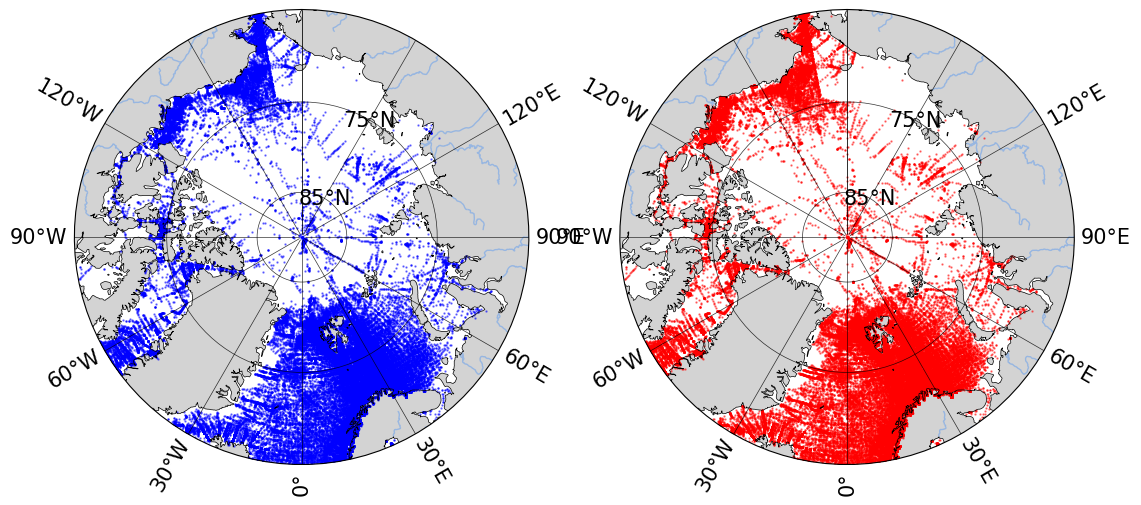

In [9]:



f,ax = plt.subplots(1,2,figsize=[10,10],subplot_kw={'projection': ccrs.NorthPolarStereo()})
ax=ax.ravel()
ftz=15


plt.subplots_adjust(top=1, bottom=0, left=0, right=1, hspace=0.3
                    ,
                    wspace=0.2)


Atools.plot_arctic_ax_map_new(ax[0])
ax[0].scatter(ds_wod_psal_new.longitude,
           ds_wod_psal_new.latitude,
           marker='.',transform=ccrs.PlateCarree(),s=2,color='blue',label='CT',alpha=0.5)

Atools.plot_arctic_ax_map_new(ax[1])
ax[1].scatter(ds_wod_temp_new.longitude,
           ds_wod_temp_new.latitude,
           marker='.',transform=ccrs.PlateCarree(),s=2,color='red',label='CT',alpha=0.5)